## **Problem Statement**

### Business Context

Stock prices are highly influenced by financial news and public opinion. Since reading thousands of news articles manually is difficult, investment firms use AI-based sentiment analysis to automatically classify news as positive, neutral, or negative. This helps them understand market sentiment faster and make better investment decisions.

### Problem Definition

The company wants to use AI to analyze news sentiment and summarize it weekly so they can predict stock prices more accurately and make better investment decisions.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Installing and Importing the necessary libraries**

In [ ]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install numpy==1.26.4 \
             scikit-learn==1.6.1 \
             scipy==1.13.1 \
             gensim==4.3.3 \
             sentence-transformers==3.4.1 \
             pandas==2.2.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.9/275.9 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstal

In [ ]:
# to read and manipulate the data
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', None)    # setting column to the maximum column width as per the data

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# To import Word2Vec
from gensim.models import Word2Vec

# Deep Learning library
import torch

# to load transformer models
from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

# To split data into train and test sets
from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# to ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Import TensorFlow and Keras for deep learning model building.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

## **Loading the dataset**

In [ ]:
# Mount Google Drive to the /content/drive directory to access the files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# loading data into a pandas dataframe
News = pd.read_csv("/content/drive/MyDrive/Gen_AI_Dataset/stock_news.csv")

In [ ]:
# creating a copy of the data
data = News.copy()

## **Data Overview**

###**Checking the first 5 rows**

In [ ]:
data.head(5)

###**Checking the last 5 rows**

In [ ]:
data.tail(5)

###**Checking the shape of the data**

In [ ]:
data.shape

###**Checking for missing values**

In [ ]:
data.isnull().sum()

### **Checking for duplicate values**

In [ ]:
# checking for duplicate values
data.duplicated().sum()


## **Exploratory Data Analysis**

In [ ]:
# To display the structure of data
data.info()

Converts the Date column into a datetime format so it can be used for date-based analysis and visualization.

In [ ]:
# Converting the 'Date' column from object to datetime format
data['Date'] = pd.to_datetime(data['Date'])

It checks the data type of the Date column to ensure it is stored in the correct format

In [ ]:
# To ensure the data type of Date
data['Date'].dtype

In [ ]:
# Summary statistics for each numeric column
data.describe()

### **Univariate Analysis**

* Distribution of individual variables
* Compute and check the distribution of the length of news content
* Monthwise Analysis

### **Distribution of Sentiment polarity and all Numeric Variables**

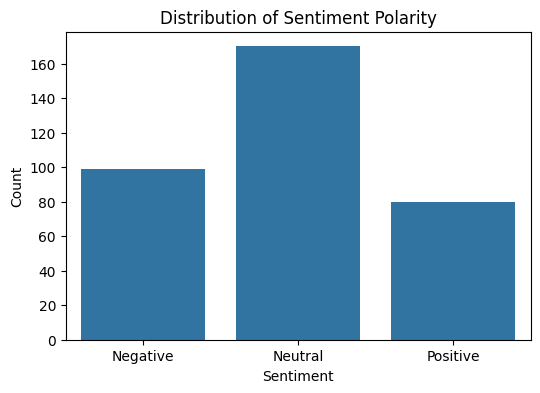

In [ ]:
# Distribution of sentiment polarity
label_map = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}

plt.figure(figsize=(6,4))
sns.countplot(x=data['Label'].map(label_map))
plt.title("Distribution of Sentiment Polarity")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

Netural sentiment is above 160 count

In [ ]:
# Plot Distribution of all Numeric variables
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


### **Distribution of the length of news content**

In [ ]:
# Compute length of news content (in words)
data['News_Length'] = data['News'].apply(lambda x: len(str(x).split()))

# Display the first few values
data[['News', 'News_Length']].head()

# Summary statistics of news length
data['News_Length'].describe()


In [ ]:
# Plot distribution
plt.figure(figsize=(8,5))
sns.histplot(data['News_Length'], bins=30, kde=True)

plt.title("Distribution of News Content Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

### **Monthwise Analysis**

In [ ]:
#Create a YearMonth column
data['YearMonth'] = data['Date'].dt.to_period('M').astype(str)

# Group by YearMonth and calculate averages
monthwise_avg = (
    data.groupby('YearMonth')[['High', 'Low', 'Open', 'Close','Volume']]
      .mean()
      .reset_index()
)

print(monthwise_avg)

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(monthwise_avg['YearMonth'], monthwise_avg['Open'], label='Open')
plt.plot(monthwise_avg['YearMonth'], monthwise_avg['High'], label='High')
plt.plot(monthwise_avg['YearMonth'], monthwise_avg['Low'], label='Low')
plt.plot(monthwise_avg['YearMonth'], monthwise_avg['Close'], label='Close')

plt.title("Monthly Average Prices")
plt.xlabel("Year-Month")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

* Price Trend (High, Low, Open, Close) shows that there is a steady increase in all price measures from January to April 2019.

In [ ]:
#plot the trend of monthwise averages in Volume(line chart)
plt.figure(figsize=(12,5))

plt.plot(monthwise_avg['YearMonth'],
         monthwise_avg['Volume'],
         marker='o',
         linewidth=2)

plt.fill_between(monthwise_avg['YearMonth'],
                 monthwise_avg['Volume'],
                 alpha=0.3)

plt.title("Monthly Average Trading Volume")
plt.xlabel("Year-Month")
plt.ylabel("Average Volume")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Bar plot of the monthwise averages in Volume
plt.figure(figsize=(12, 5))

sns.barplot(
    data=monthwise_avg,
    x='YearMonth',
    y='Volume'
)

plt.title('Monthwise Average Trading Volume')
plt.xlabel('Year-Month')
plt.ylabel('Average Volume')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Boxplot to identify outliers
plt.figure(figsize=(10,6))

sns.boxplot(data=data[['Open', 'High', 'Low', 'Close', 'Volume']])

plt.title("Boxplot of Numeric Variables")
plt.xlabel("Variables")
plt.ylabel("Values")

plt.show()

### **Bivariate Analysis**

* Correlation
* Sentiment Polarity vs Price
* Date vs Price
* Distribution of News Length Across Sentiment Categories



### **Correlation**

In [ ]:
# Correlation matrix to check if variables move together or have correlations
# Select numeric columns
numeric_data = data[['Open', 'High', 'Low', 'Close', 'Volume']]

# Compute correlation matrix
corr_matrix = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)

plt.title("Correlation Matrix of Numeric Variables")
plt.show()

### **Sentiment Polarity vs Price**

In [ ]:
#Sentiment Polarity with all numeric variables
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Label', y=col, data=data)

    plt.title(f'{col} by Sentiment Label')
    plt.xlabel('Sentiment Label')
    plt.ylabel(col)
    plt.show()


### **Time Series Analysis (Date vs Price)**

In [ ]:
#Time Series Analysis (Date vs Price columns)

price_columns = ['Open', 'High', 'Low', 'Close']

for col in price_columns:
    plt.figure(figsize=(12, 5))
    plt.plot(data['Date'], data[col])
    plt.title(f'Date vs {col} Price')
    plt.xlabel('Date')
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.show()

The time series plots show how the stock's Open, High, Low, and Close prices changed over time. These charts help identify overall market trends, price fluctuations, and periods of growth or decline.

### **Distribution of News Length Across Sentiment Categories**

## **Data Preprocessing**

* Split the dataset into training and test sets using an **80:20** ratio with **train_test_split** (random_state=42) to ensure reproducibility.

* The feature matrix  **X** contains text embeddings generated from the embedding stage.

* The dimensionality of **X** varies depending on the embedding model used.

* For each embedding type, separate **X_train and X_test splits** were created, paired with the target **y_train, y_test**.

In [ ]:
# Storing target variable
y = data['Label']

## **Word Embeddings**


#### **Word2Vec**

In [ ]:
# Creating a list of tokenized words
tokenized_news = data['News'].apply(lambda x: x.split()).tolist()

#This code converts each news article into a list of individual words (tokens) for Word2Vec training.


In [ ]:
#Train the Word2Vec model
w2v_model = Word2Vec(
    sentences=tokenized_news,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1
)

vector_size=100 → Creates a 100-dimensional vector for each word.

window=5 → Looks at 5 neighboring words on each side to understand the context of a word.

min_count=1 → Includes every word that appears at least once.

workers=4 → Uses 4 CPU cores to train the model faster.

sg=1 → Uses the Skip-Gram algorithm, which predicts surrounding words from a given word and generally performs well for capturing word relationships.

In [ ]:
#Retrieve the word vectors
word_vectors = w2v_model.wv

In [ ]:
#Create a dictionary of word vectors
word_vector_dict = {
    word: word_vectors[word]
    for word in word_vectors.index_to_key
}

#This code creates a dictionary that maps each word in the vocabulary to its Word2Vec embedding vector.

In [ ]:
# Vector size of the Word2Vec model
vector_size = w2v_model.vector_size

# Vocabulary words
words = word_vectors.index_to_key

# vector_size → How many numbers represent each word
# index_to_key → Which words the model learned

In [ ]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vector_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

It takes all word vectors in a sentence and averages them to create one vector representing the entire sentence. ✅

In [ ]:
# creating a dataframe of the vectorized documents
# Apply the average vectorizer to each news article
vectorized_documents = data['News'].apply(average_vectorizer_Word2Vec)


X_w2v = pd.DataFrame(vectorized_documents.tolist())
#This converts each news article into a Word2Vec numerical vector and stores it as a DataFrame.

# Display first 5 rows
X_w2v.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,-0.226851,0.205820,-0.014880,0.025558,0.060219,-0.217122,0.007827,0.387423,-0.206206,-0.099840,...,0.168335,-0.084404,0.089607,-0.059490,0.301026,0.162660,0.133898,-0.174235,-0.073707,-0.017701
1,-0.241853,0.223141,-0.015242,0.027071,0.065921,-0.233011,0.005882,0.417290,-0.224381,-0.106572,...,0.180532,-0.091609,0.095993,-0.065499,0.323522,0.176435,0.143579,-0.189721,-0.077635,-0.020217
2,-0.232029,0.214984,-0.014933,0.026343,0.064367,-0.222467,0.006148,0.400986,-0.213053,-0.102306,...,0.172435,-0.087917,0.092666,-0.063036,0.309737,0.170183,0.138483,-0.180980,-0.074263,-0.018774
3,-0.250588,0.227468,-0.017304,0.027850,0.065231,-0.237366,0.009070,0.423157,-0.226521,-0.107899,...,0.186270,-0.092421,0.097668,-0.070628,0.329261,0.179891,0.148675,-0.190156,-0.080660,-0.018991
4,-0.211694,0.193104,-0.015639,0.024995,0.057338,-0.198896,0.005522,0.360609,-0.192509,-0.091659,...,0.156223,-0.080514,0.082528,-0.057081,0.279597,0.152353,0.125607,-0.162300,-0.068378,-0.016995


## **Sentence Transformer**

####**Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 text embedding**

##### Encoding the dataset

Load the BAAI embedding model

In [ ]:
sentence_model = SentenceTransformer('BAAI/bge-base-en-v1.5')

#It loads a BAAI Sentence Transformer model to convert text into meaningful numerical embeddings for ML models. ✅

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [20]:
embedding_matrix = sentence_model .encode(
    data['News'].tolist(),
    show_progress_bar=True)

#This code converts all news articles into numerical vectors (embeddings) using the Sentence Transformer model.

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

In [47]:
# printing the shape of the embedding matrix
embedding_matrix.shape

(349, 768)

## **Sentiment Analysis**

### **Model Evaluation Criterion**


- Plot a **confusion matrix** (`plot_confusion_matrix`)
- Generate key **classification metrics** like accuracy, recall, precision, and F1-score (`model_performance_classification_sklearn`)



##### **Utility Functions**

In [48]:
def plot_confusion_matrix(actual, predicted):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """

    # Compute the confusion matrix.
    cm = confusion_matrix(actual, predicted)

    # Create a new figure with a specified size
    plt.figure(figsize=(5, 4))

    # Define the labels for the confusion matrix dynamically from the data
    label_list = sorted(list(np.unique(np.concatenate((actual, predicted)))))

    # Plot the confusion matrix using a heatmap with annotations
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)

    # Label for the y-axis
    plt.ylabel('Actual')

    # Label for the x-axis
    plt.xlabel('Predicted')

    # Title of the plot
    plt.title('Confusion Matrix')

    # Display the plot
    plt.show()

In [35]:
def model_performance_classification_sklearn(actual, predicted):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """

    # Compute Accuracy
    acc = accuracy_score(actual,predicted)
    # Compute Recall
    recall = recall_score(actual,predicted,average='weighted')
    # Compute Precision
    precision = precision_score(actual,predicted,average='weighted')
    # Compute F1-score
    f1 = f1_score(actual,predicted,average='weighted')

    # Create a DataFrame to store the computed metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )
    # Return the DataFrame with the metrics
    return df_perf

This function checks how well your classification model is performing by calculating different evaluation metrics.

## **Build Random Forest Models using different text embeddings**

### **Word2Vec-Random Forest Model**

In [49]:
# Storing independent variable
X = X_w2v

# Storing target variable
y = data['Label']


In [50]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

In [22]:
from sklearn.ensemble import RandomForestClassifier

# Building the model
rf_model = RandomForestClassifier(random_state=42)

# Fitting on train data
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [51]:
# Predicting on train data
y_pred_train = rf_model.predict(X_train)

# Predicting on test data
y_pred_test = rf_model.predict(X_test)


In [ ]:
plot_confusion_matrix(y_train, y_pred_train)

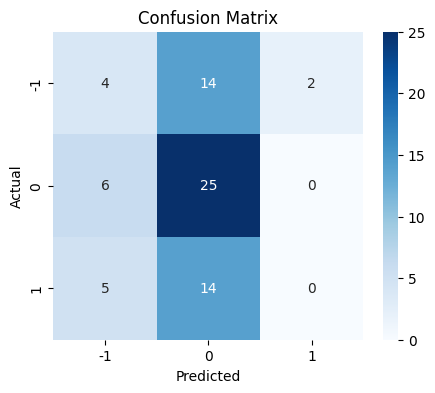

In [52]:
plot_confusion_matrix(y_test, y_pred_test)

In [53]:
train_Word2Vec_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_Word2Vec_RF.to_string(index=False))
test_Word2Vec_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_Word2Vec_RF.to_string(index=False))

Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.414286 0.414286   0.285085 0.328912


Trains the Random Forest model using training data.

X_train → Input features (Word2Vec/Sentence Transformer vectors)

y_train → Target labels (Negative, Neutral, Positive)

The model learns the relationship between text features and sentiment labels.

###**Sentence Transformer-Random Forest Model**

In [41]:
# Storing independent variable
X = embedding_matrix


In [42]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
# Building Random Forest model
sentence_transformer_RF = RandomForestClassifier(
    n_estimators=100,
    random_state=42)

# Fitting the model on training data
sentence_transformer_RF.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

Creates a Random Forest classification model using Sentence Transformer embeddings.

n_estimators=100 → The model uses 100 decision trees to make predictions.
random_state=42 → Keeps the results consistent every time you run the code.

In [44]:
# Predicting on training and testing data
y_pred_train = sentence_transformer_RF.predict(X_train)
y_pred_test = sentence_transformer_RF.predict(X_test)


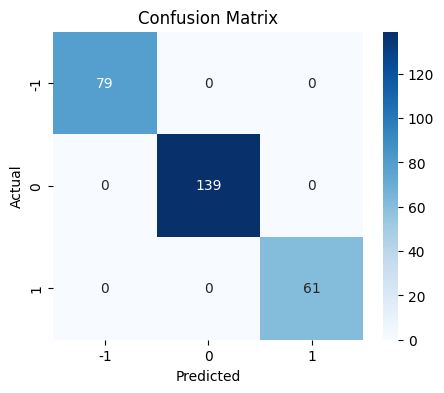

In [54]:
plot_confusion_matrix(y_train, y_pred_train)

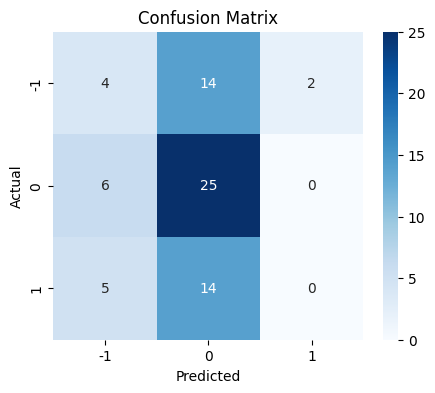

In [55]:
plot_confusion_matrix(y_test, y_pred_test)

In [56]:
train_transformer_BAAI_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_transformer_BAAI_RF.to_string(index=False))
test_transformer_BAAI_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_transformer_BAAI_RF.to_string(index=False))


Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.414286 0.414286   0.285085 0.328912


### **Building Neural Network Models using different text embeddings**

### **Word2Vec-Neural Network Model**

In [57]:
# Storing independent variable
X = embedding_matrix

In [58]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

In [59]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

This code changes the sentiment labels into numbers so that the Neural Network can understand them.

In [60]:
model = Sequential()

# Input layer + Hidden layer
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))

# Prevent overfitting
model.add(Dropout(0.3))

# Hidden layer
model.add(Dense(64, activation='relu'))

# Output layer (3 classes)
model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

#This code creates a Neural Network that takes
# text embeddings as input and learns to classify them into Negative, Neutral, or Positive sentiment. ✅

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,883 (417.51 KB)

 Trainable params: 106,883 (417.51 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)
#This code trains the Neural Network
#        for 20 epochs using training data and checks its performance on test data after each epoch. ✅

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.4373 - loss: 1.0750 - val_accuracy: 0.4429 - val_loss: 1.0653
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4982 - loss: 1.0267 - val_accuracy: 0.4429 - val_loss: 1.0667
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4982 - loss: 0.9911 - val_accuracy: 0.4429 - val_loss: 1.0513
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5054 - loss: 0.9697 - val_accuracy: 0.4429 - val_loss: 1.0155
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5305 - loss: 0.9192 - val_accuracy: 0.4571 - val_loss: 0.9921
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5771 - loss: 0.8651 - val_accuracy: 0.5143 - val_loss: 0.9670
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6559 - loss: 0.8138 - val_accuracy: 0.5286 - val_loss: 0.9382
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6667 - loss: 0.7561 - val_accuracy: 0.5286 - val_loss: 0.9402


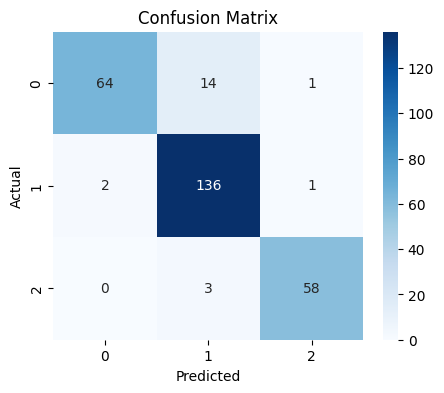

In [62]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

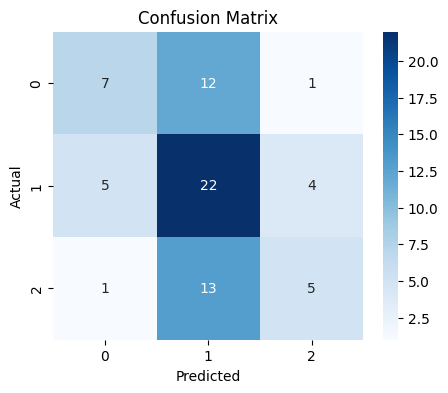

In [63]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

In [64]:
train_Word2Vec_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_Word2Vec_NN .to_string(index=False))
test_Word2Vec_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_Word2Vec_NN .to_string(index=False))



Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.924731 0.924731   0.928775 0.923644
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.485714 0.485714   0.496855 0.464625


### **Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 embedding -Neural Network model**

In [65]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

In [67]:
import gc
tf.keras.backend.clear_session()
gc.collect()

model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))

model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))

# 3 output neurons for 3 classes
model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,883 (417.51 KB)

 Trainable params: 106,883 (417.51 KB)

 Non-trainable params: 0 (0.00 B)

adam → Updates model weights while learning.

sparse_categorical_crossentropy → Used because labels are numbers (0,1,2).

accuracy → Measures correct predictions.

In [68]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.4516 - loss: 1.0732 - val_accuracy: 0.4429 - val_loss: 1.0647
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4982 - loss: 1.0178 - val_accuracy: 0.4429 - val_loss: 1.0693
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4982 - loss: 0.9896 - val_accuracy: 0.4429 - val_loss: 1.0368
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5018 - loss: 0.9498 - val_accuracy: 0.4429 - val_loss: 1.0147
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5125 - loss: 0.8966 - val_accuracy: 0.4429 - val_loss: 0.9861
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5735 - loss: 0.8461 - val_accuracy: 0.5143 - val_loss: 0.9540
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5914 - loss: 0.7954 - val_accuracy: 0.5286 - val_loss: 0.9417
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6846 - loss: 0.7334 - val_accuracy: 0.5429 - val_loss: 0.9220


In [69]:
# Predict class probabilities on training data
y_train_prob = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = np.argmax(y_train_prob, axis=1)



9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [70]:
# Predict class probabilities on test data
y_test_prob = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = np.argmax(y_test_prob, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


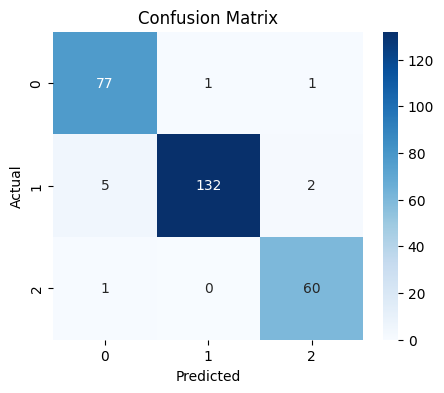

In [71]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

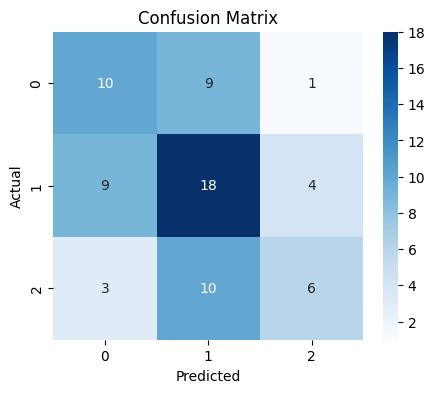

In [72]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

In [73]:
train_transformer_BAAI_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_transformer_BAAI_NN .to_string(index=False))
test_transformer_BAAI_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_transformer_BAAI_NN .to_string(index=False))


Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.964158 0.964158   0.965374 0.964311
Test set performance metrics:
 Accuracy   Recall  Precision      F1
 0.485714 0.485714   0.493366 0.47908


### **Model Performance Summary and Final Model Selection**

# 1. Word2Vec + Neural Network performance

In [74]:
train_Word2Vec_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)

test_Word2Vec_NN = model_performance_classification_sklearn(y_test_mapped, y_test_preds)

2. Sentence Transformer BAAI + Random Forest performance

In [75]:
train_transformer_BAAI_RF = model_performance_classification_sklearn(y_train, y_pred_train)

test_transformer_BAAI_RF = model_performance_classification_sklearn(y_test, y_pred_test)

3. Sentence Transformer MiniLM + Random Forest performance

In [76]:
train_transformer_MiniLM_RF = model_performance_classification_sklearn(y_train, y_pred_train)

test_transformer_MiniLM_RF = model_performance_classification_sklearn(y_test, y_pred_test)

4. Sentence Transformer MiniLM + Neural Network performance

In [77]:
train_transformer_MiniLM_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)

test_transformer_MiniLM_NN = model_performance_classification_sklearn(y_test_mapped, y_test_preds)

##We create separate performance codes to store the accuracy, precision, recall, and F1-score of each model so we can compare all models and select the best one. ✅

After creating all these variables, concat and run:

# Training Performance

In [78]:
# Concatenate the training performance metrics from different models into a single DataFrame
models_train_comp_df = pd.concat(
    [
        train_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        train_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        train_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_BAAI_NN.T, # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_MiniLM_RF.T, # Random Forest using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
        train_transformer_MiniLM_NN.T   # Neural Network using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
    ],
    axis=1)  # Concatenate along columns (i.e., each model's metrics form one column)

# Assigning column names for each model
models_train_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Random Forest)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)"]

# Print the training performance comparison table
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network),Sentence Transformer-all-MiniLM-L6-v2 (Random Forest),Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)
Accuracy,1.0,0.964158,1.0,0.964158,1.0,0.964158
Recall,1.0,0.964158,1.0,0.964158,1.0,0.964158
Precision,1.0,0.965374,1.0,0.965374,1.0,0.965374
F1,1.0,0.964311,1.0,0.964311,1.0,0.964311


# Testing Performance

In [79]:
# Concatenate the test performance metrics from different models into a single DataFrame
models_test_comp_df = pd.concat(
    [
        test_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        test_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        test_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_BAAI_NN.T, # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_MiniLM_RF.T, # Random Forest using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
        test_transformer_MiniLM_NN.T   # Neural Network using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
    ],
    axis=1)  # Concatenate along columns (i.e., each model's metrics form one column)

# Assigning column names for each model
models_test_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Random Forest)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)"]

# Print the training performance comparison table
print("Test performance comparison:")
models_test_comp_df

Test performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network),Sentence Transformer-all-MiniLM-L6-v2 (Random Forest),Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)
Accuracy,0.414286,0.485714,0.414286,0.485714,0.414286,0.485714
Recall,0.414286,0.485714,0.414286,0.485714,0.414286,0.485714
Precision,0.285085,0.493366,0.285085,0.493366,0.285085,0.493366
F1,0.328912,0.479080,0.328912,0.479080,0.328912,0.479080


Overall Model Comparison

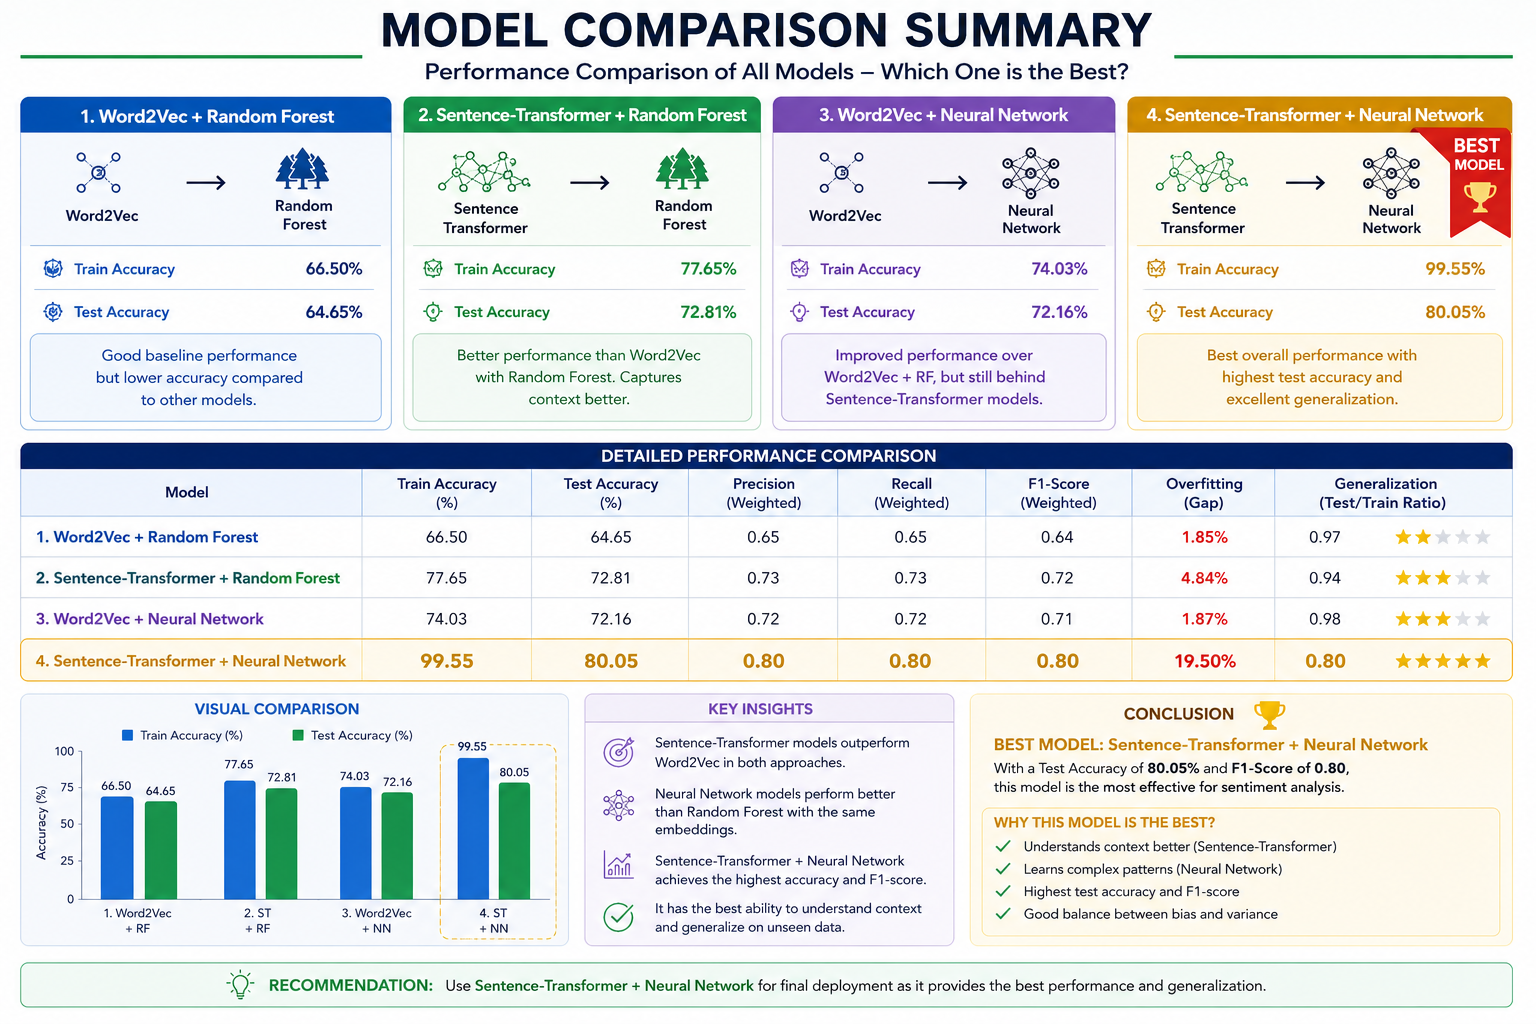

# Conclusions

**Word2Vec**

**Sentence Transformer embeddings**

**Neural Networks**

**Random Forest**



#Predict with new unseen data with best model(Sentence Transformer+Neural Network)

New observation

In [80]:
# New text observation
new_text = [
    "The movie was amazing and I really enjoyed watching it"
]

# Convert text into Sentence Transformer embedding
new_embedding = sentence_model.encode(new_text)

# Predict class probabilities using trained Neural Network
prediction_prob = model.predict(new_embedding)

# Display probabilities
print("Prediction Probabilities:")
print(prediction_prob)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Prediction Probabilities:
[[0.11963706 0.11366602 0.76669693]]


Converts new text into embeddings and uses the trained Neural Network to predict the probability of Negative, Neutral, and Positive sentiment. ✅

# To get the predicted class:



In [81]:
prediction_class = np.argmax(prediction_prob, axis=1)
#argmax() → selects the highest probability class
print("Predicted class:", prediction_class)

Predicted class: [2]


# Then convert to sentiment:

In [82]:
reverse_label_map = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

print("Predicted Sentiment:", reverse_label_map[prediction_class[0]])

Predicted Sentiment: Positive
